In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

from scipy.sparse import hstack

import warnings
warnings.filterwarnings("ignore")

In [11]:
df = pd.read_csv("anime.csv")

In [10]:
 df.shape

(12294, 7)

In [12]:
df.dtypes

anime_id      int64
name         object
genre        object
type         object
episodes     object
rating      float64
members       int64
dtype: object

In [13]:
df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [14]:
df.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [15]:
# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

# Convert episodes to numeric
df["episodes"] = pd.to_numeric(
    df["episodes"],
    errors="coerce"
)

# Fill missing categorical values
df["genre"] = df["genre"].fillna("Unknown")
df["type"] = df["type"].fillna("Unknown")

# Fill missing numerical values
for col in ["episodes", "rating", "members"]:
    df[col] = df[col].fillna(
        df[col].median()
    )

# Remove rows without anime names
df = df.dropna(
    subset=["name"]
).reset_index(drop=True)

print("Shape After Preprocessing:", df.shape)

print("\nMissing Values After Preprocessing:")
print(df.isnull().sum())

Shape After Preprocessing: (12294, 7)

Missing Values After Preprocessing:
anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64


In [18]:
print("Summary Statistics:")
display(
    df[
        [
            "episodes",
            "rating",
            "members"
        ]
    ].describe()
)



Summary Statistics:


,episodes,rating,members
count,12294.000000,12294.000000,1.229400e+04
mean,12.095412,6.475700,1.807134e+04
std,46.244062,1.017179,5.482068e+04
min,1.000000,1.670000,5.000000e+00
25%,1.000000,5.900000,2.250000e+02
50%,2.000000,6.570000,1.550000e+03
75%,12.000000,7.170000,9.437000e+03
max,1818.000000,10.000000,1.013917e+06


In [17]:
print("\nAnime Types:")
print(
    df["type"]
    .value_counts()
)


Anime Types:
type
TV         3787
OVA        3311
Movie      2348
Special    1676
ONA         659
Music       488
Unknown      25
Name: count, dtype: int64


In [6]:
# Combine genre and type
df["text_features"] = (
    df["genre"].astype(str)
    + " "
    + df["type"].astype(str)
)

# Convert categorical text features into numerical TF-IDF features
tfidf = TfidfVectorizer(
    token_pattern=r"(?u)\b[\w-]+\b"
)

text_matrix = tfidf.fit_transform(
    df["text_features"]
)

print(
    "TF-IDF Feature Matrix Shape:",
    text_matrix.shape
)

TF-IDF Feature Matrix Shape: (12294, 52)


In [7]:
# Numerical features required for similarity
numeric_columns = [
    "episodes",
    "rating",
    "members"
]

scaler = StandardScaler()

numeric_matrix = scaler.fit_transform(
    df[numeric_columns]
)

print(
    "Scaled Numerical Feature Shape:",
    numeric_matrix.shape
)

Scaled Numerical Feature Shape: (12294, 3)


In [8]:
# Combine categorical TF-IDF features
# with normalised numerical features
feature_matrix = hstack(
    [
        text_matrix,
        numeric_matrix
    ]
)

print(
    "Final Feature Matrix Shape:",
    feature_matrix.shape
)

Final Feature Matrix Shape: (12294, 55)


In [9]:
cosine_sim = cosine_similarity(
    feature_matrix
)

print(
    "Cosine Similarity Matrix Shape:",
    cosine_sim.shape
)

Cosine Similarity Matrix Shape: (12294, 12294)


In [10]:
# Map anime names to dataset indices
anime_indices = pd.Series(
    df.index,
    index=df["name"].str.lower()
).drop_duplicates()

print("Anime Index Created Successfully")

Anime Index Created Successfully


In [19]:
def recommend_anime(
    anime_name,
    threshold=0.20,
    top_n=10
):
    
    anime_name = anime_name.lower().strip()

    # Check whether anime exists
    if anime_name not in anime_indices.index:
        print(
            "Anime not found in dataset."
        )
        return pd.DataFrame()

    # Get index of target anime
    idx = anime_indices[anime_name]

    # Get similarity scores
    similarity_scores = list(
        enumerate(
            cosine_sim[idx]
        )
    )

    # Sort by similarity score
    similarity_scores = sorted(
        similarity_scores,
        key=lambda x: x[1],
        reverse=True
    )

    recommendations = []

    # Skip the target anime itself
    for i, score in similarity_scores[1:]:

        if score >= threshold:

            recommendations.append(
                [
                    df.iloc[i]["name"],
                    df.iloc[i]["genre"],
                    df.iloc[i]["type"],
                    df.iloc[i]["episodes"],
                    df.iloc[i]["rating"],
                    df.iloc[i]["members"],
                    round(score, 4)
                ]
            )

        if len(recommendations) >= top_n:
            break

    return pd.DataFrame(
        recommendations,
        columns=[
            "Anime",
            "Genre",
            "Type",
            "Episodes",
            "Rating",
            "Members",
            "Cosine Similarity"
        ]
    )

In [12]:
# Select an anime that exists in the dataset
target_anime = df["name"].iloc[0]

print(
    "Target Anime:",
    target_anime
)

recommendations = recommend_anime(
    target_anime,
    threshold=0.20,
    top_n=10
)

display(recommendations)

Target Anime: Kimi no Na wa.


,Anime,Genre,Type,Episodes,Rating,Members,Cosine Similarity
0,Hotarubi no Mori e,"Drama, Romance, Shoujo, Supernatural",Movie,1.0,8.61,197439,0.9762
1,Suzumiya Haruhi no Shoushitsu,"Comedy, Mystery, Romance, School, Sci-Fi, Supe...",Movie,1.0,8.81,240297,0.9682
2,"Clannad: After Story - Mou Hitotsu no Sekai, K...","Drama, Romance, School",Special,1.0,8.02,138364,0.9607
3,Hotaru no Haka,"Drama, Historical",Movie,1.0,8.58,174878,0.9594
4,Haikyuu!! Second Season,"Comedy, Drama, School, Shounen, Sports",TV,25.0,8.93,179342,0.9563
5,Sakamichi no Apollon,"Drama, Josei, Music, Romance, School",TV,12.0,8.48,146592,0.9559
6,Majo no Takkyuubin,"Adventure, Comedy, Drama, Fantasy, Magic, Romance",Movie,1.0,8.27,152331,0.9554
7,Tenkuu no Shiro Laputa,"Adventure, Fantasy, Romance, Sci-Fi",Movie,1.0,8.38,151061,0.9527
8,Monogatari Series: Second Season,"Comedy, Mystery, Romance, Supernatural, Vampire",TV,26.0,8.80,205959,0.9515
9,"Clannad: Mou Hitotsu no Sekai, Tomoyo-hen","Drama, Romance, School, Slice of Life",Special,1.0,8.14,160423,0.9513


In [13]:
thresholds = [
    0.10,
    0.20,
    0.30,
    0.40,
    0.50,
    0.60
]

threshold_results = []

for threshold in thresholds:

    result = recommend_anime(
        target_anime,
        threshold=threshold,
        top_n=100
    )

    threshold_results.append(
        [
            threshold,
            len(result)
        ]
    )

threshold_results = pd.DataFrame(
    threshold_results,
    columns=[
        "Similarity Threshold",
        "Number of Recommendations"
    ]
)

display(threshold_results)

,Similarity Threshold,Number of Recommendations
0,0.1,100
1,0.2,100
2,0.3,100
3,0.4,100
4,0.5,100
5,0.6,100


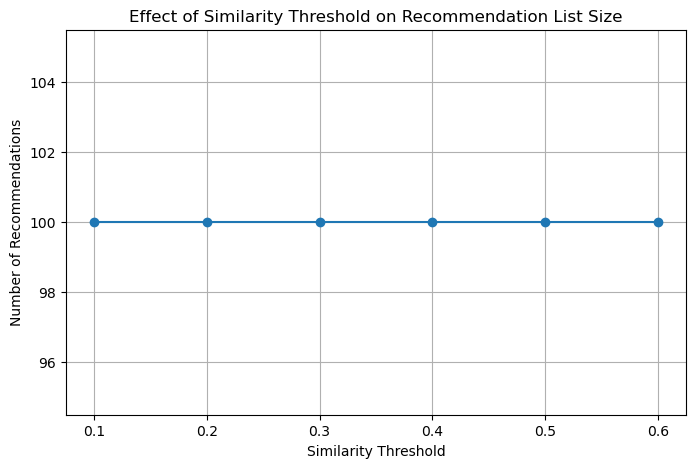

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results[
        "Similarity Threshold"
    ],
    threshold_results[
        "Number of Recommendations"
    ],
    marker="o"
)

plt.title(
    "Effect of Similarity Threshold "
    "on Recommendation List Size"
)

plt.xlabel(
    "Similarity Threshold"
)

plt.ylabel(
    "Number of Recommendations"
)

plt.grid(True)

plt.show()

## Performance Analysis
#### Anime similarity is calculated via cosine similarity using genre, media type, episodes, rating, and member count.A lower threshold generates a broader recommendation list with lower similarity standards.A higher threshold enforces stricter matching, returning fewer but more relevant titles.Users can adjust this sensitivity to balance recommendation volume against accuracy.

## AREAS FOR IMPROVEMENT
#### Leverage past user ratings for tailored recommendations.Apply collaborative filtering using user-item interaction patterns.Build a hybrid system combining both content-based and collaborative approaches.Treat distinct genres as individual feature vectors for granular similarity scoring.Measure recommendation quality using Precision@K, Recall@K, and direct user feedback loops

## FINAL CONCLUSION

#### We successfully built a content-based recommendation model powered by cosine similarity.TF-IDF vectorization transformed genre and type into numerical values, and continuous features were normalised for balanced similarity scoring.The system matches target anime with similar titles based on their combined feature vector.Experiments show that a higher cutoff threshold yields fewer but more strictly aligned recommendations.Integrating user feedback and collaborative approaches represents the most logical next step for improvement.

## INTERVIEW QUESTIONS & ANSWERS


#### Q1: Difference between User-Based and Item-Based Collaborative Filtering?
##### User-Based CF finds users with similar preferences and recommends items they liked.Item-Based CF finds items that share similar rating patterns and recommends items similar to what the target user already enjoys.Summary: User-Based matches user-to-user; Item-Based matches item-to-item.

### Q2: What is Collaborative Filtering and How Does It Work?
#### Collaborative Filtering generates recommendations using historical user interaction data (ratings, views, purchases) instead of item metadata.
##### Workflow:
##### 1. Collect user-item interactions into a matrix.
##### 2. Calculate user/item similarity scores (e.g., Cosine Similarity).
##### 3. Predict interest scores for unseen items.
##### 4. Return the top-ranked recommendations.